Количество дней с сильным дождем (больше 3 мм) - 41
Количество всех дождливых дней - 79, сухих - 13
Количество холодных ночей (ниже +3 градусов) - 0
Количество жарких дней (температура +30 и выше) - 4


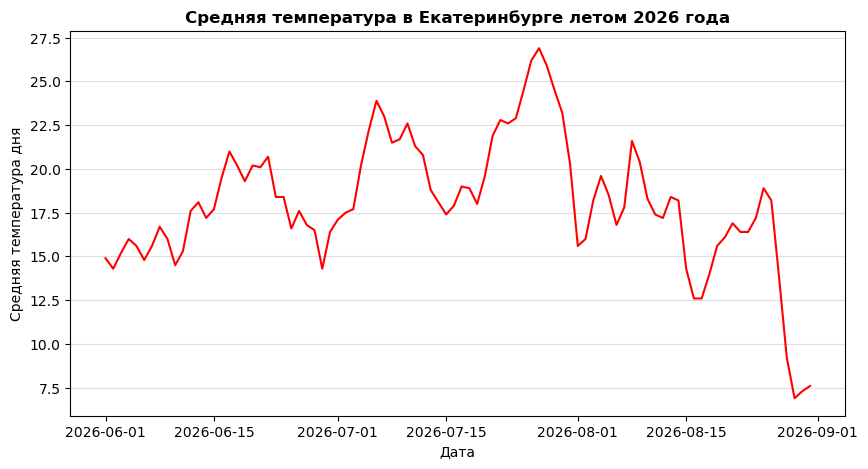

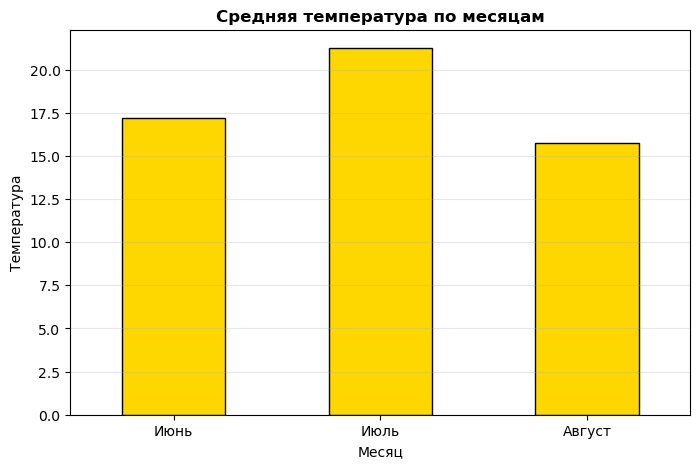

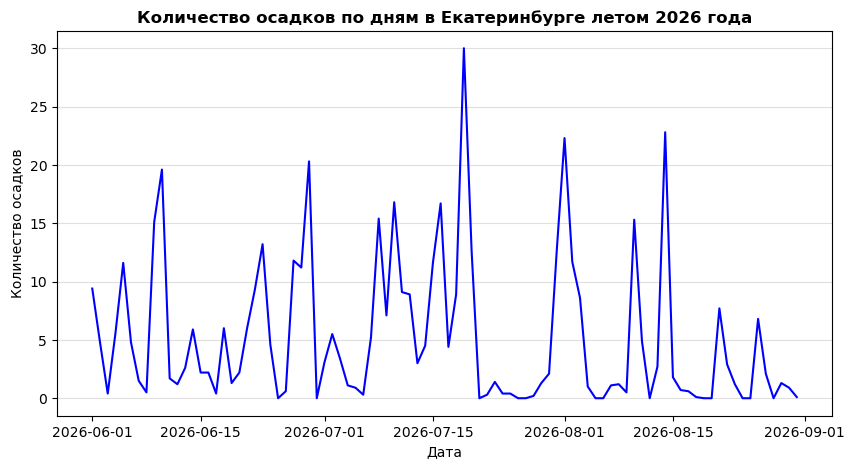

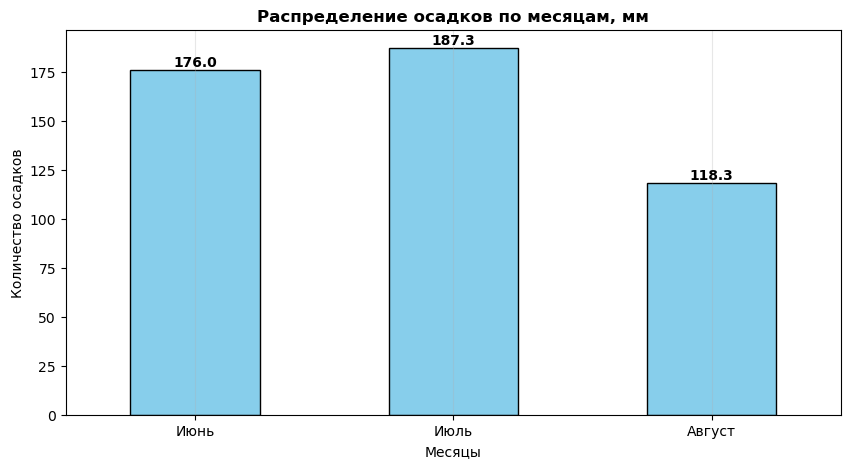

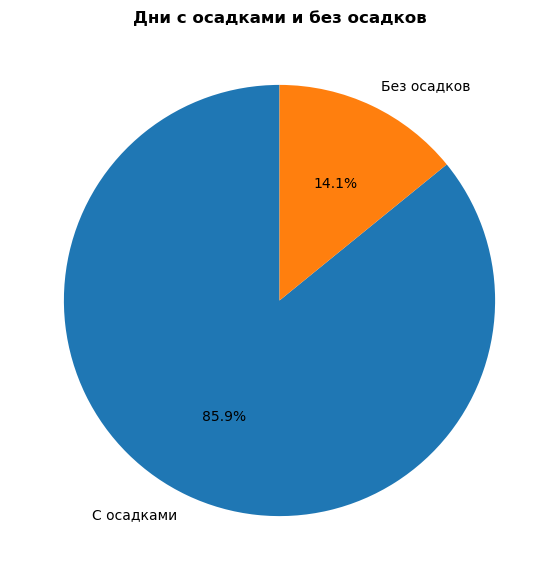

Самый дождливый день был 2026-07-19 00:00:00, выпало 30.0 мм осадков
Дни с осадками составили 85.9% лета
ВЫВОД: лето 2026 года в Екатеринбурге было теплым, но очень дождливым. Дожди шли 79 дней, выпало 482 миллиметров за 3 месяца


In [44]:
#АНАЛИЗ ПОГОДЫ ЗА ЛЕТО 2026 ГОДА В ЕКАТЕРИНБУРГЕ
import requests
import pandas as pd
import matplotlib.pyplot as plt


url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 56.8519,
    "longitude": 60.6122,
    "start_date": "2026-06-01",
    "end_date": "2026-08-31",
    "daily": "temperature_2m_mean,temperature_2m_min,temperature_2m_max,precipitation_sum",
    "timezone": "Asia/Yekaterinburg"
}

response = requests.get(url, params=params)
response.raise_for_status()
    
data = response.json()
    
daily_data = data["daily"]
    
df = pd.DataFrame(daily_data)

df = df.rename(columns={
    "time": "Дата",
    "temperature_2m_mean": "Средняя_температура_С",
    "temperature_2m_min": "Мин_температура_С",
    "temperature_2m_max": "Макс_температура_С",
    "precipitation_sum": "Осадки_мм"
})
    
df["Дата"] = pd.to_datetime(df["Дата"])
    
#print("Сводка погоды в Екатеринбурге за лето 2026 года:")
#print(df.head())

df["Дождливые_дни"] = df["Осадки_мм"].apply(lambda x: 1 if x > 3 else 0)
print(f"Количество дней с сильным дождем (больше 3 мм) - {df["Дождливые_дни"].sum()}")

df["День_с_осадками"] = df["Осадки_мм"].apply(lambda x: 1 if x > 0 else 0)
rainy_days = df["День_с_осадками"].sum()
dry_days = len(df) - rainy_days
print(f"Количество всех дождливых дней - {rainy_days}, сухих - {dry_days}")

precip_sum = df["Осадки_мм"].sum()

df["Холодные_ночи"] = df["Мин_температура_С"].apply(lambda x: 1 if x < 3 else 0)
print(f"Количество холодных ночей (ниже +3 градусов) - {df["Холодные_ночи"].sum()}")

df["Жаркие_дни"] = df["Макс_температура_С"].apply(lambda x: 1 if x >= 30 else 0)
print(f"Количество жарких дней (температура +30 и выше) - {df["Жаркие_дни"].sum()}")

plt.figure(figsize = (10, 5))
plt.plot(df["Дата"], df["Средняя_температура_С"], color="red")
plt.xlabel("Дата")
plt.ylabel("Средняя температура дня")
plt.title("Средняя температура в Екатеринбурге летом 2026 года", fontsize=12, fontweight="bold")
plt.grid(axis="y", alpha=0.4)
plt.show()

df["Месяц"] = df["Дата"].dt.month
monthly_temperature = df.groupby("Месяц")["Средняя_температура_С"].mean()
plt.figure(figsize=(8, 5))
monthly_temperature.plot(kind="bar", color="gold", edgecolor="black")
plt.title("Средняя температура по месяцам", fontsize=12, fontweight="bold")
plt.xlabel("Месяц")
plt.ylabel("Температура")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.xticks([0, 1, 2], ["Июнь", "Июль", "Август"])
plt.show()

plt.figure(figsize = (10, 5))
plt.plot(df["Дата"], df["Осадки_мм"], color="blue")
plt.xlabel("Дата")
plt.ylabel("Количество осадков")
plt.title("Количество осадков по дням в Екатеринбурге летом 2026 года", fontsize=12, fontweight="bold")
plt.grid(axis="y", alpha=0.4)
plt.show()

monthly_precipitation = df.groupby("Месяц")["Осадки_мм"].sum()
plt.figure(figsize=(10, 5))
monthly_precipitation.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Распределение осадков по месяцам, мм", fontsize=12, fontweight="bold")
for i, v in enumerate(monthly_precipitation):
    plt.text(i, v+2, str(v), ha="center", fontweight="bold")
plt.xlabel("Месяцы")
plt.ylabel("Количество осадков")
plt.xticks(rotation=0)
plt.grid(axis="x", alpha=0.3)
plt.xticks([0, 1, 2], ["Июнь", "Июль", "Август"])
plt.show()

plt.figure(figsize=(7, 7))
plt.pie([rainy_days, dry_days], labels=["С осадками", "Без осадков"], autopct="%1.1f%%", startangle=90)
plt.title("Дни с осадками и без осадков", fontsize=12, fontweight="bold")
plt.show()

max_precip = df["Осадки_мм"].max()
most_rainy_day = df.loc[df["Осадки_мм"].idxmax(), "Дата"]
print(f"Самый дождливый день был {most_rainy_day}, выпало {max_precip} мм осадков")

rainy_percent = rainy_days / len(df) * 100
print(f"Дни с осадками составили {rainy_percent:.1f}% лета")

print(f"ВЫВОД: лето 2026 года в Екатеринбурге было теплым, но очень дождливым. Дожди шли {
rainy_days} дней, выпало {precip_sum:.0f} миллиметра за 3 месяца")